In [ ]:
#exploring green space dataset


In [2]:
#explore csv
import pandas as pd
import os

csv_path = "data/parks/Parks.csv"
parks_df = pd.read_csv(csv_path)

In [3]:
#explore csv
parks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OBJECTID       418 non-null    int64  
 1   Asset_ID       418 non-null    object 
 2   Type           418 non-null    object 
 3   Name           417 non-null    object 
 4   Playgrounds    418 non-null    object 
 5   ESRI_OID       418 non-null    int64  
 6   Shape__Area    418 non-null    float64
 7   Shape__Length  418 non-null    float64
dtypes: float64(2), int64(2), object(4)
memory usage: 26.3+ KB


In [4]:
parks_df.describe()

,OBJECTID,ESRI_OID,Shape__Area,Shape__Length
count,418.000000,418.000000,418.000000,418.000000
mean,2900.619617,209.500000,4869.669610,285.490750
std,2617.659050,120.810458,21310.396882,381.124653
min,3.000000,1.000000,35.340088,30.696993
25%,115.250000,105.250000,337.910339,83.941002
50%,3578.500000,209.500000,973.869446,167.348464
75%,4376.750000,313.750000,3061.736633,321.306809
max,39532.000000,418.000000,390302.581421,3948.935422


In [5]:
parks_df.head()

,OBJECTID,Asset_ID,Type,Name,Playgrounds,ESRI_OID,Shape__Area,Shape__Length
0,3,PK24,Pocket,The Green,No,1,434.778564,146.768594
1,4,PK46,Neighbourhood,Barney and Bligh Reserve,No,2,1930.490601,182.041819
2,5,PK47,Pocket,Dawes Point Park west,No,3,728.362549,180.369182
3,6,PK54,Pocket,Viaduct Area #4 Wash Away,No,4,1316.813110,157.568751
4,7,PK62,Pocket,Ada Place Park,No,5,228.287598,61.552752


In [6]:
#exploring the shapefile

In [7]:
import geopandas as gpd

shapefile_path = 'data/parks/Parks.shp'
parks_gdf = gpd.read_file(shapefile_path)

In [8]:
parks_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    418 non-null    int32   
 1   Asset_ID    418 non-null    object  
 2   Type        418 non-null    object  
 3   Name        417 non-null    object  
 4   Playground  418 non-null    object  
 5   ESRI_OID    418 non-null    int32   
 6   Shape__Are  418 non-null    float64 
 7   Shape__Len  418 non-null    float64 
 8   geometry    418 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(4)
memory usage: 26.3+ KB


In [9]:
parks_gdf.head()

,OBJECTID,Asset_ID,Type,Name,Playground,ESRI_OID,Shape__Are,Shape__Len,geometry
0,3,PK24,Pocket,The Green,No,1,434.778564,146.768594,"MULTIPOLYGON (((334082.183 6246763.783, 334077..."
1,4,PK46,Neighbourhood,Barney and Bligh Reserve,No,2,1930.490601,182.041819,"POLYGON ((334315.838 6252014.475, 334324.282 6..."
2,5,PK47,Pocket,Dawes Point Park west,No,3,728.362549,180.369182,"POLYGON ((334213.414 6252333.008, 334211.584 6..."
3,6,PK54,Pocket,Viaduct Area #4 Wash Away,No,4,1316.813110,157.568751,"POLYGON ((335330.759 6250456.781, 335333.32 62..."
4,7,PK62,Pocket,Ada Place Park,No,5,228.287598,61.552752,"POLYGON ((333215.943 6250145.93, 333210.479 62..."


In [10]:
parks_gdf.columns

Index(['OBJECTID', 'Asset_ID', 'Type', 'Name', 'Playground', 'ESRI_OID',
       'Shape__Are', 'Shape__Len', 'geometry'],
      dtype='object')

<Axes: >

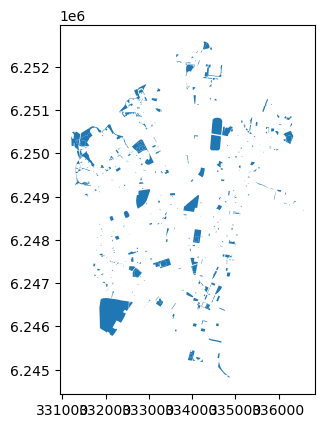

In [11]:
parks_gdf.plot()

In [12]:
parks_gdf.explore()

In [13]:
#exploring my villages shapefile

In [14]:
shapefile2_path = "data/villages/Our_villages.shp"
villages_gdf = gpd.read_file(shapefile2_path)

In [15]:
villages_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    10 non-null     int32   
 1   Name        10 non-null     object  
 2   Code        10 non-null     object  
 3   Shape__Are  10 non-null     float64 
 4   Shape__Len  10 non-null     float64 
 5   geometry    10 non-null     geometry
dtypes: float64(2), geometry(1), int32(1), object(2)
memory usage: 572.0+ bytes


In [ ]:
villages_gdf.head()

In [17]:
villages_gdf.columns

Index(['OBJECTID', 'Name', 'Code', 'Shape__Are', 'Shape__Len', 'geometry'], dtype='object')

In [ ]:
#renaming my columns


<Axes: >

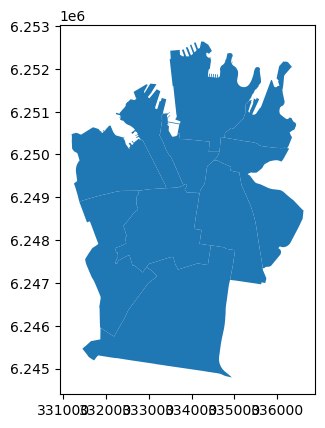

In [18]:
villages_gdf.plot()

In [19]:
villages_gdf.explore()

In [20]:
#checking crs of villages vs parks

In [21]:
#using spatial joins in order to join the villages and the parks

In [23]:
parks_in_villages = gpd.overlay(parks_gdf, villages_gdf, how='intersection')

In [24]:
parks_in_villages["park_area_m2"] = parks_in_villages.geometry.area

In [27]:
park_stats = parks_in_villages.groupby("Name").agg(
    total_parks=("geometry", "count"),
    total_park_area=("park_area_m2", "sum")
).reset_index()

KeyError: 'Name'